# Блок A: Подготовка эконометрических данных

**Цель этапа:** превратить разрозненные источники (ИПЦ-компоненты от Росстата + дневная панель эмоций из Telegram) в чистый набор временных рядов, готовый для DFM и MFBVAR.

**Что делаем:**
1. **Парсинг и очистка ИПЦ:** 54 компонента ИПЦ, m/m % с устранённой сезонностью, 2002-01 → 2026-03
2. **Стационарность:** ADF и KPSS тесты для всех рядов; идентификация порядка интеграции I(d)
3. **Дескриптивная статистика и графика:** структурные сдвиги, выбросы, режимы инфляции
4. **Дневная панель эмоций:** загрузка результатов NLP-этапа
5. **Выбор окна анализа:** на основе плотности данных в эмоциях (msg_volume) выбираем оптимальный период для эконометрики
6. **Агрегация эмоций до месячной частоты** (для DFM на m/m ИПЦ) и **до недельной** (для MFBVAR)
7. **Финальный merge:** датасет, готовый для моделирования

**Что в результате:** три CSV-файла (`monthly_panel.csv`, `weekly_panel.csv`, `daily_emotions_clean.csv`) + полный отчёт по стационарности + графика для ВКР.

## 1. Установка и импорты

Этот ноутбук можно запускать локально (на твоём Mac) или в Colab — он не требует GPU.

In [ ]:
# Если в чистом Colab/окружении:
!pip install pandas numpy openpyxl statsmodels matplotlib seaborn pyarrow --quiet

import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'  # для русского

## 2. Загрузка ИПЦ-компонентов из indicators_cpd.xlsx

**Содержание файла:** 54 компонента ИПЦ России в формате темпов прироста к предыдущему месяцу (m/m %), сезонность устранена методом X-13 ARIMA-SEATS. Источник — Банк России / Росстат, набор используется при подготовке заседаний Совета по ДКП.

**Период:** январь 2002 — март 2026 (291 месяц).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Для Colab:
CPI_PATH = '/content/drive/MyDrive/diploma/indicators_cpd.xlsx'

wb = openpyxl.load_workbook(CPI_PATH, read_only=True, data_only=True)
ws = wb['Лист1']
all_data = list(ws.iter_rows(values_only=True))

# Первая строка: индикатор + даты
dates_raw = all_data[0][1:]

# Собираем валидные индикаторы (отсекаем сноски и пустые строки)
valid_rows = []
for i, row in enumerate(all_data[1:], start=2):
    name = row[0]
    if name and not str(name).startswith(('1 -', '2 -', '*', 'Примеч')):
        valid_rows.append((i, str(name).strip()))

data_dict = {}
for row_idx, name in valid_rows:
    values = all_data[row_idx-1][1:]
    data_dict[name] = values

df_cpi = pd.DataFrame(data_dict, index=pd.to_datetime(dates_raw))
df_cpi.index.name = 'date'
df_cpi = df_cpi.apply(pd.to_numeric, errors='coerce')

print(f'Размер: {df_cpi.shape[0]} месяцев × {df_cpi.shape[1]} индикаторов')
print(f'Период: {df_cpi.index.min():%Y-%m} — {df_cpi.index.max():%Y-%m}')
print(f'\nПервые 5 индикаторов:')
for c in df_cpi.columns[:5]:
    print(f'  - {c}')

Размер: 291 месяцев × 54 индикаторов
Период: 2002-01 — 2026-03

Первые 5 индикаторов:
  - Все товары и услуги
  - - без плодоовощной продукции, нефтепродуктов и ЖКХ
  - Продовольственные товары
  - -без плодоовощной продукции
  - Мясопродукты


## 3. Аудит пропусков и качество данных

In [ ]:
nan_counts = df_cpi.isna().sum().sort_values(ascending=False)
n_with_nan = (nan_counts > 0).sum()
print(f'Индикаторов с пропусками: {n_with_nan} из {df_cpi.shape[1]}')
print(f'\nIndicators with most missing values:')
print(nan_counts[nan_counts > 0])

# Удаляем сильно неполные ряды (>20% пропусков) — для DFM это шум
threshold = int(df_cpi.shape[0] * 0.2)
to_drop = nan_counts[nan_counts > threshold].index.tolist()
if to_drop:
    print(f'\nУдаляем индикаторы с >{threshold} пропусками:')
    for c in to_drop:
        print(f'  - {c} ({nan_counts[c]} NaN)')
    df_cpi = df_cpi.drop(columns=to_drop)

# Оставшиеся пропуски (< 20%) интерполируем
df_cpi = df_cpi.interpolate(method='linear', limit_direction='both')
print(f'\nИтоговая размерность после очистки: {df_cpi.shape}')

Индикаторов с пропусками: 3 из 54

Indicators with most missing values:
Инструменты и оборудование    144
Средства связи                 12
Персональные компьютеры        12
dtype: int64

Удаляем индикаторы с >58 пропусками:
  - Инструменты и оборудование (144 NaN)

Итоговая размерность после очистки: (291, 53)


## 4. Дескриптивная статистика и режимная динамика инфляции

**Что считаем:**
- Базовая описательная статистика по 6 ключевым агрегатам
- Разбиение по периодам (выявление структурных сдвигов)
- График динамики headline и core inflation

In [ ]:
key_aggregates = [
    'Все товары и услуги',
    '- без плодоовощной продукции, нефтепродуктов и ЖКХ',
    'Продовольственные товары',
    'Непродовольственные товары',
    'Услуги',
    'Базовый ИПЦ',
]
key_aggregates = [c for c in key_aggregates if c in df_cpi.columns]

print('=== Дескриптивная статистика (m/m % с уст. сезонностью) ===')
desc = df_cpi[key_aggregates].describe().T[['mean', 'std', 'min', '50%', 'max']]
desc.columns = ['Mean', 'Std', 'Min', 'Median', 'Max']
print(desc.round(3))

# Аннуализированные значения (для интерпретации в %)
print('\n=== Annualized (m/m × 12, для удобства интерпретации) ===')
ann = df_cpi[key_aggregates].mean() * 12
print(ann.round(2).to_frame('Avg annual inflation, %'))

=== Дескриптивная статистика (m/m % с уст. сезонностью) ===
                                                     Mean    Std    Min  \
Все товары и услуги                                 0.694  0.579 -0.316   
- без плодоовощной продукции, нефтепродуктов и ЖКХ  0.661  0.592 -0.097   
Продовольственные товары                            0.714  0.743 -0.778   
Непродовольственные товары                          0.553  0.713 -0.382   
Услуги                                              0.889  0.669 -0.172   
Базовый ИПЦ                                         0.651  0.623 -0.104   

                                                    Median     Max  
Все товары и услуги                                  0.602   7.495  
- без плодоовощной продукции, нефтепродуктов и ЖКХ   0.569   8.391  
Продовольственные товары                             0.588   6.624  
Непродовольственные товары                           0.474  11.236  
Услуги                                               0.699   4.025  


In [ ]:
# Режимы инфляции по эпохам
df_cpi_temp = df_cpi.copy()
df_cpi_temp['period'] = pd.cut(
    df_cpi_temp.index.year,
    bins=[2001, 2014, 2021, 2024, 2027],
    labels=['2002-2014: high inflation', '2015-2021: targeting', '2022-2024: shocks', '2025-2026: recent']
)

regime_stats = df_cpi_temp.groupby('period', observed=True)[key_aggregates[0]].agg(['mean', 'std']).round(3)
regime_stats.columns = ['Mean m/m, %', 'Std m/m']
regime_stats['Annualized mean, %'] = (regime_stats['Mean m/m, %'] * 12).round(2)
print('=== Режимы инфляции (Headline) ===')
print(regime_stats)

=== Режимы инфляции (Headline) ===
                           Mean m/m, %  Std m/m  Annualized mean, %
period                                                             
2002-2014: high inflation        0.810    0.360                9.72
2015-2021: targeting             0.476    0.453                5.71
2022-2024: shocks                0.777    1.222                9.32
2025-2026: recent                0.507    0.247                6.08


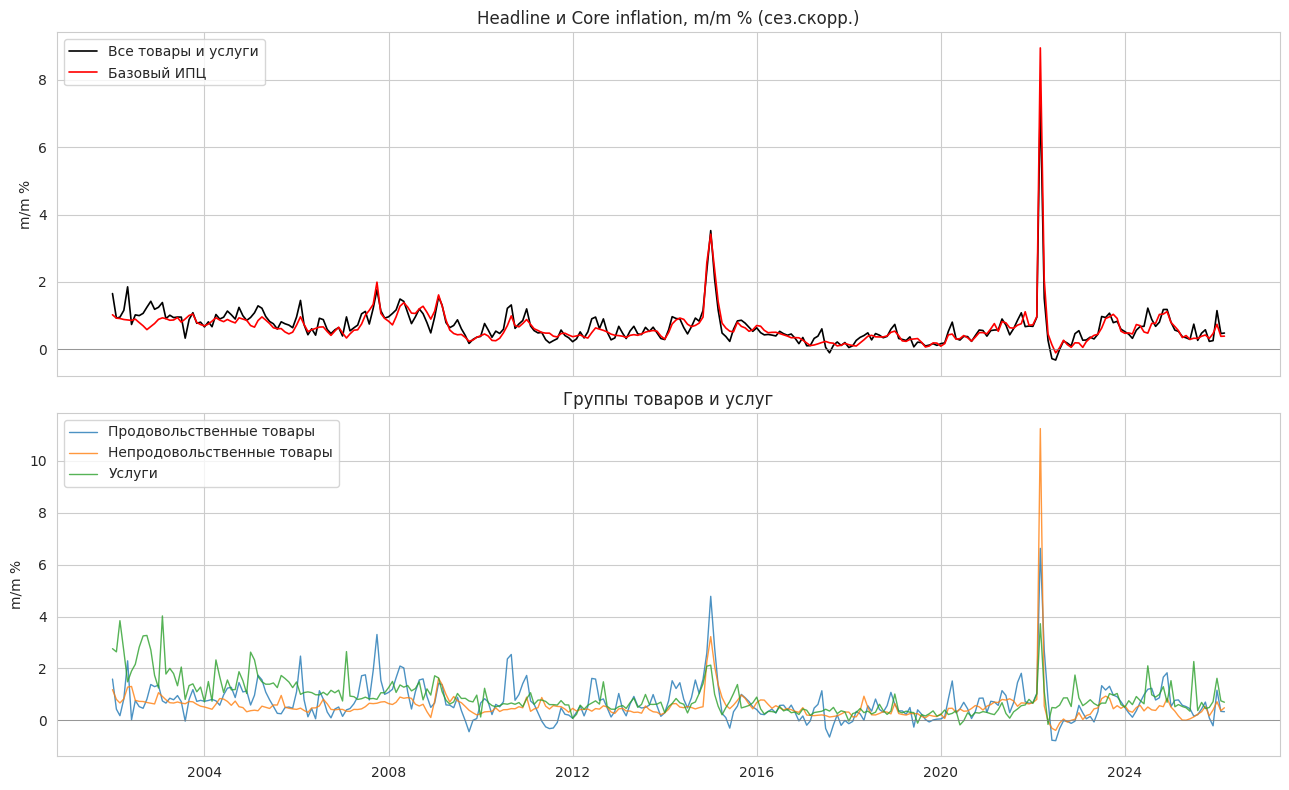

In [ ]:
# Главный график для ВКР: динамика основных компонентов
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Headline + Core
for col, c in zip(['Все товары и услуги', 'Базовый ИПЦ'], ['black', 'red']):
    axes[0].plot(df_cpi.index, df_cpi[col], color=c, linewidth=1.2, label=col)
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].set_title('Headline и Core inflation, m/m % (сез.скорр.)', fontsize=12)
axes[0].legend(loc='upper left')
axes[0].set_ylabel('m/m %')

# Группы: Продовольственные / Непродовольственные / Услуги
groups = ['Продовольственные товары', 'Непродовольственные товары', 'Услуги']
for col in groups:
    if col in df_cpi.columns:
        axes[1].plot(df_cpi.index, df_cpi[col], linewidth=1.0, label=col, alpha=0.8)
axes[1].axhline(0, color='grey', linewidth=0.5)
axes[1].set_title('Группы товаров и услуг', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].set_ylabel('m/m %')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/diploma/cpi_components_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Стационарность: ADF и KPSS тесты

**Зачем это нужно:**

Перед DFM/VAR/BVAR нужно убедиться, что ряды стационарны. Если ряд I(1) (нестационарен на уровнях, но стационарен в первых разностях), его нужно либо дифференцировать, либо моделировать через cointegration framework. Если ряд I(0) — можно использовать как есть.

**Двойной тест ADF + KPSS — стандартная практика** (Kwiatkowski et al., 1992):
- ADF: $H_0$ — есть единичный корень; отвергаем при $p < 0.05$ → ряд **стационарен**
- KPSS: $H_0$ — ряд стационарен; **не** отвергаем при $p > 0.05$ → ряд **стационарен**
- Если ADF и KPSS противоречат — ряд возможно дробно интегрирован или содержит структурный сдвиг

**Гипотеза:** темпы прироста (m/m %) с устранённой сезонностью почти всегда I(0). Это будет ожидаемо, но проверить нужно — это требование рецензентов.

In [ ]:
def stationarity_tests(series, name):
    """Возвращает результаты ADF и KPSS для ряда."""
    s = series.dropna()
    if len(s) < 30:
        return None
    try:
        adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    except Exception as e:
        adf_stat, adf_p = np.nan, np.nan
    try:
        kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    except Exception as e:
        kpss_stat, kpss_p = np.nan, np.nan

    # Решение на основе двух тестов
    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = 'I(0) — stationary'
    elif adf_p > 0.05 and kpss_p < 0.05:
        verdict = 'I(1) — needs differencing'
    elif adf_p < 0.05 and kpss_p < 0.05:
        verdict = 'Conflict (possibly trend-stationary)'
    else:
        verdict = 'Inconclusive'

    return {
        'indicator': name, 'n_obs': len(s),
        'ADF_stat': round(adf_stat, 3), 'ADF_p': round(adf_p, 4),
        'KPSS_stat': round(kpss_stat, 3), 'KPSS_p': round(kpss_p, 4),
        'verdict': verdict
    }

results = []
for col in df_cpi.columns:
    res = stationarity_tests(df_cpi[col], col)
    if res:
        results.append(res)

stat_df = pd.DataFrame(results)
print(f'Всего протестировано: {len(stat_df)}')
print(f'\nРаспределение вердиктов:')
print(stat_df['verdict'].value_counts())

# Показываем нестационарные (если есть)
non_stat = stat_df[stat_df['verdict'] != 'I(0) — stationary']
if len(non_stat) > 0:
    print(f'\n=== Не I(0) индикаторы ({len(non_stat)}): ===')
    print(non_stat.to_string(index=False))
else:
    print('\n✓ Все ряды стационарны I(0) — готовы к DFM/VAR без дополнительной трансформации')

Всего протестировано: 53

Распределение вердиктов:
verdict
I(0) — stationary                       31
Conflict (possibly trend-stationary)    16
I(1) — needs differencing                6
Name: count, dtype: int64

=== Не I(0) индикаторы (22): ===
                                   indicator  n_obs  ADF_stat  ADF_p  KPSS_stat  KPSS_p                              verdict
                         Все товары и услуги    291   -10.495 0.0000      0.803  0.0100 Conflict (possibly trend-stationary)
                         Алкогольные напитки    291    -2.036 0.2710      0.569  0.0260            I(1) — needs differencing
                        Общественное питание    291    -2.665 0.0803      1.260  0.0100            I(1) — needs differencing
                              Одежда и белье    291    -3.990 0.0015      1.598  0.0100 Conflict (possibly trend-stationary)
                      Меха и меховые изделия    291    -1.734 0.4137      2.122  0.0100            I(1) — needs differencing
  

## 6. Загрузка дневной панели эмоций (результат NLP-этапа)

In [ ]:
# Дневная панель из этапа NLP — должна была сохраниться при инференсе на полный корпус
DAILY_EMOTIONS_PATH = '/content/drive/MyDrive/diploma/daily_emotion_indicators_6cls.csv'
# Локально:
# DAILY_EMOTIONS_PATH = '/Users/user/Desktop/diploma/daily_emotion_indicators_6cls.csv'

df_emo = pd.read_csv(DAILY_EMOTIONS_PATH, index_col=0, parse_dates=True)
df_emo.index.name = 'date'
print(f'Дневная панель: {df_emo.shape}')
print(f'Период: {df_emo.index.min():%Y-%m-%d} — {df_emo.index.max():%Y-%m-%d}')
print(f'\nКолонки:')
for c in df_emo.columns:
    print(f'  - {c}')
print(f'\nПервые 3 строки:')
print(df_emo.head(3).round(3))

Дневная панель: (3129, 14)
Период: 2017-09-15 — 2026-04-15

Колонки:
  - p_Aggression_mean
  - p_Anxiety_mean
  - p_Disappointment_mean
  - p_Hope_mean
  - p_Neutral_mean
  - p_Uncertainty_mean
  - p_Aggression_wmean
  - p_Anxiety_wmean
  - p_Disappointment_wmean
  - p_Hope_wmean
  - p_Neutral_wmean
  - p_Uncertainty_wmean
  - emotion_entropy
  - msg_volume

Первые 3 строки:
            p_Aggression_mean  p_Anxiety_mean  p_Disappointment_mean  \
date                                                                   
2017-09-15              0.013           0.202                  0.049   
2017-09-16              0.022           0.892                  0.009   
2017-09-17              0.006           0.017                  0.043   

            p_Hope_mean  p_Neutral_mean  p_Uncertainty_mean  \
date                                                          
2017-09-15        0.009           0.646               0.082   
2017-09-16        0.011           0.035               0.030   
2017-09-1

## 7. Анализ плотности данных и выбор окна анализа

**Ключевой вопрос:** с какого момента дневные эмоциональные индикаторы становятся статистически содержательными?

Если в день всего 1-2 сообщения, средняя вероятность класса определяется одним текстом и сильно шумит. Минимально приемлемое значение `msg_volume` — обычно 10-20 сообщений в день.

Плотность данных по годам:
      n_days  total_msgs  median_msgs_per_day  p10_msgs  p90_msgs
year                                                             
2017     103         614                    5         1        11
2018     365        5239                   15         5        23
2019     364        5006                   14         6        20
2020     366        6649                   19         7        28
2021     365        9652                   30        11        37
2022     365      139858                  420        30       667
2023     365      133738                  373       153       579
2024     366      189708                  536       211       817
2025     365      119220                  309       160       512
2026     105       33648                  309       158       516


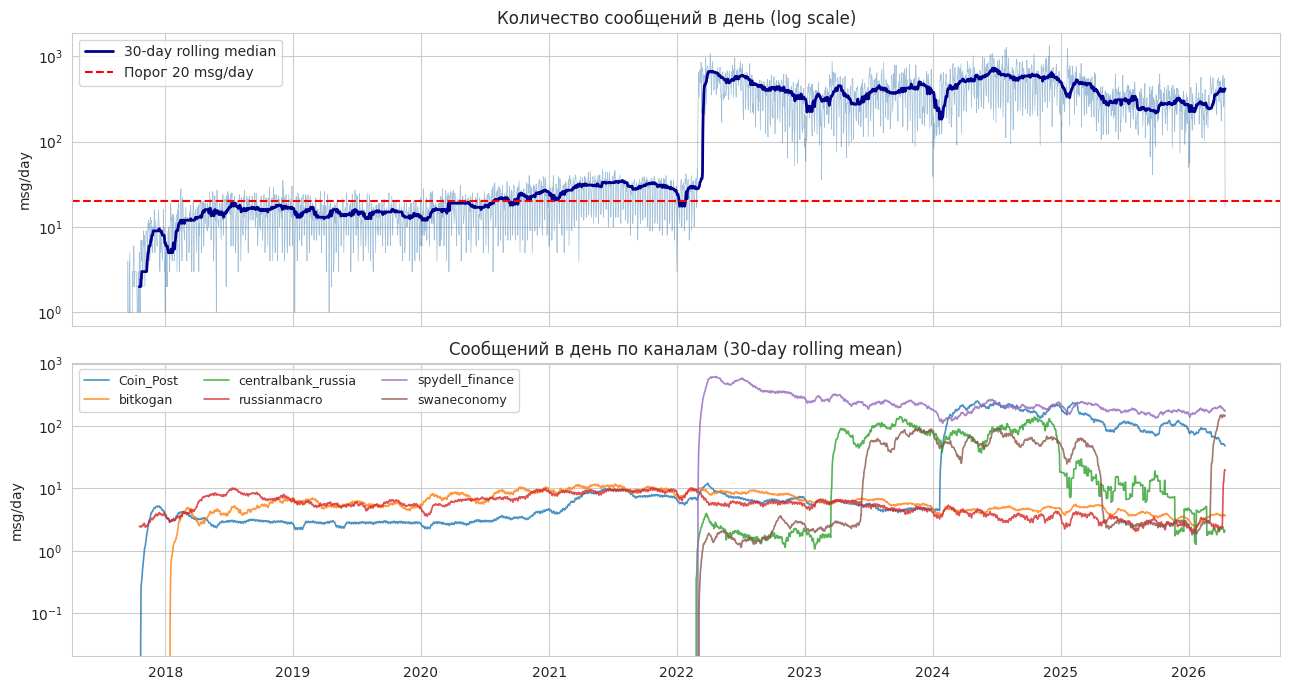

In [ ]:
# График количества сообщений по дням (по годам)
df_emo['year'] = df_emo.index.year
yearly = df_emo.groupby('year').agg(
    n_days=('msg_volume', 'count'),
    total_msgs=('msg_volume', 'sum'),
    median_msgs_per_day=('msg_volume', 'median'),
    p10_msgs=('msg_volume', lambda x: x.quantile(0.1)),
    p90_msgs=('msg_volume', lambda x: x.quantile(0.9)),
).astype(int)

print('Плотность данных по годам:')
print(yearly)

# График — log scale для удобства
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(df_emo.index, df_emo['msg_volume'], linewidth=0.5, alpha=0.5, color='steelblue')
axes[0].plot(df_emo.index, df_emo['msg_volume'].rolling(30).median(), color='darkblue', linewidth=2,
             label='30-day rolling median')
axes[0].axhline(20, color='red', linestyle='--', label='Порог 20 msg/day')
axes[0].set_yscale('log')
axes[0].set_title('Количество сообщений в день (log scale)')
axes[0].legend()
axes[0].set_ylabel('msg/day')

# Динамика по каналам — нужна отдельная агрегация (не из daily)
# Если есть полный корпус: загрузим
FULL_CORPUS_PATH = '/content/drive/MyDrive/diploma/full_corpus_with_emotions_6cls.parquet'
try:
    df_full = pd.read_parquet(FULL_CORPUS_PATH)
    df_full['day'] = pd.to_datetime(df_full['date']).dt.tz_localize(None).dt.floor('D')
    by_channel = df_full.groupby(['day', 'channel']).size().unstack(fill_value=0)
    by_channel = by_channel.rolling(30).mean()
    for ch in by_channel.columns:
        axes[1].plot(by_channel.index, by_channel[ch], label=ch, alpha=0.8, linewidth=1.2)
    axes[1].set_title('Сообщений в день по каналам (30-day rolling mean)')
    axes[1].legend(ncol=3, loc='upper left', fontsize=9)
    axes[1].set_ylabel('msg/day')
    axes[1].set_yscale('log')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Не удалось загрузить full corpus: {e}', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/diploma/emotion_data_density.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Какой период проходит порог msg_volume >= 20?
df_emo['ok'] = df_emo['msg_volume'] >= 20
print('Доля дней с msg_volume >= 20 по годам:')
print((df_emo.groupby('year')['ok'].mean() * 100).round(1).astype(str) + ' %')

# Найдём первую дату, с которой стабильно >=20 (rolling 30 дней)
rolling_ok = df_emo['ok'].rolling(30, min_periods=20).mean()
first_stable = rolling_ok[rolling_ok >= 0.5].first_valid_index()
print(f'\nПервый стабильный период (≥50% дней с msg_volume>=20 в окне 30 дней): {first_stable}')

Доля дней с msg_volume >= 20 по годам:
year
2017      0.0 %
2018     21.1 %
2019     12.1 %
2020     46.2 %
2021     70.7 %
2022     93.7 %
2023    100.0 %
2024    100.0 %
2025    100.0 %
2026     99.0 %
Name: ok, dtype: object

Первый стабильный период (≥50% дней с msg_volume>=20 в окне 30 дней): 2020-04-28 00:00:00


## 8. Решение о периоде анализа

**Логика выбора:**
1. Период должен начинаться после `first_stable` (когда дневные индикаторы стабильны)
2. Длина должна быть достаточной для DFM (ориентир: 60+ месяцев)
3. Заканчиваем последним полным месяцем ИПЦ (март 2026)

**После взгляда на цифры выбираем стартовую точку и фиксируем её.**

In [ ]:
# === ВЫБОР ПЕРИОДА (зависит от того, что покажет диагностика выше) ===
# Адаптируй после просмотра графика плотности!

# Вариант: автоматически от first_stable, скруглённого до начала месяца
if first_stable is not None:
    auto_start = first_stable.to_period('M').to_timestamp()
    print(f'Автоматически предлагаемый старт: {auto_start:%Y-%m}')

# Финальный выбор (можно переписать вручную после просмотра)
ANALYSIS_START = pd.Timestamp('2020-01-01')   # <-- меняй здесь
ANALYSIS_END = pd.Timestamp('2026-03-31')

n_months = (ANALYSIS_END.year - ANALYSIS_START.year) * 12 + (ANALYSIS_END.month - ANALYSIS_START.month) + 1
print(f'Финальное окно анализа: {ANALYSIS_START:%Y-%m} — {ANALYSIS_END:%Y-%m} ({n_months} месяцев)')

# Применяем
df_cpi_use = df_cpi.loc[ANALYSIS_START:ANALYSIS_END]
df_emo_use = df_emo.loc[ANALYSIS_START:ANALYSIS_END]

print(f'\nИПЦ обрезанный: {df_cpi_use.shape}')
print(f'Эмоции обрезанные: {df_emo_use.shape}')

Автоматически предлагаемый старт: 2020-04
Финальное окно анализа: 2020-01 — 2026-03 (75 месяцев)

ИПЦ обрезанный: (75, 53)
Эмоции обрезанные: (2282, 16)


## 9. Агрегация эмоций до месячной частоты

Для DFM на месячном ИПЦ нам нужны эмоции в той же частоте.

**Стратегия агрегации:**
- Средние значения вероятностей классов за месяц (`p_*_mean`) → месячный индекс эмоции
- Volume-weighted средние (`p_*_wmean`) → версия с поправкой на охват
- Энтропия дневных распределений, усреднённая за месяц → индекс поляризации
- Логарифм месячного объёма сообщений как контрольная переменная

In [ ]:
df_emo_m = df_emo_use.copy()
df_emo_m.index = df_emo_m.index.to_period('M').to_timestamp()  # начало месяца

prob_cols_mean = [c for c in df_emo_m.columns if c.endswith('_mean') and not c.endswith('_wmean')]
prob_cols_wmean = [c for c in df_emo_m.columns if c.endswith('_wmean')]

monthly_emo = df_emo_m.groupby(df_emo_m.index).agg(
    {**{c: 'mean' for c in prob_cols_mean + prob_cols_wmean},
     'emotion_entropy': 'mean',
     'msg_volume': 'sum'}
)
monthly_emo['log_msg_volume'] = np.log(monthly_emo['msg_volume'].clip(lower=1))

print(f'Месячная панель эмоций: {monthly_emo.shape}')
print(f'\nПервые 3 месяца:')
print(monthly_emo.head(3).round(3))
print(f'\nПоследние 3 месяца:')
print(monthly_emo.tail(3).round(3))

Месячная панель эмоций: (75, 15)

Первые 3 месяца:
            p_Aggression_mean  p_Anxiety_mean  p_Disappointment_mean  \
date                                                                   
2020-01-01              0.064           0.286                  0.050   
2020-02-01              0.039           0.384                  0.043   
2020-03-01              0.042           0.486                  0.037   

            p_Hope_mean  p_Neutral_mean  p_Uncertainty_mean  \
date                                                          
2020-01-01        0.046           0.409               0.145   
2020-02-01        0.045           0.341               0.148   
2020-03-01        0.040           0.263               0.131   

            p_Aggression_wmean  p_Anxiety_wmean  p_Disappointment_wmean  \
date                                                                      
2020-01-01               0.070            0.288                   0.049   
2020-02-01               0.044            0.396

## 10. Стационарность эмоциональных рядов

Доли эмоций — ограниченные сверху (0,1) переменные, обычно довольно стационарны. Но проверить нужно.

In [ ]:
emo_results = []
for col in monthly_emo.columns:
    if col != 'msg_volume':  # объём отдельно — он точно нестационарен
        res = stationarity_tests(monthly_emo[col], col)
        if res:
            emo_results.append(res)

emo_stat_df = pd.DataFrame(emo_results)
print('Стационарность эмоциональных рядов:')
print(emo_stat_df[['indicator', 'ADF_p', 'KPSS_p', 'verdict']].to_string(index=False))

non_stat_emo = emo_stat_df[emo_stat_df['verdict'] != 'I(0) — stationary']
if len(non_stat_emo) > 0:
    print(f'\nНестационарные эмоциональные ряды ({len(non_stat_emo)}):')
    print(non_stat_emo[['indicator', 'verdict']].to_string(index=False))
    print('\nДля них применим первые разности перед DFM.')

Стационарность эмоциональных рядов:
             indicator  ADF_p  KPSS_p                              verdict
     p_Aggression_mean 0.7427  0.0100            I(1) — needs differencing
        p_Anxiety_mean 0.4198  0.0100            I(1) — needs differencing
 p_Disappointment_mean 0.6425  0.0100            I(1) — needs differencing
           p_Hope_mean 0.7613  0.0100            I(1) — needs differencing
        p_Neutral_mean 0.0310  0.0463 Conflict (possibly trend-stationary)
    p_Uncertainty_mean 0.5304  0.0100            I(1) — needs differencing
    p_Aggression_wmean 0.3446  0.0100            I(1) — needs differencing
       p_Anxiety_wmean 0.0012  0.1000                    I(0) — stationary
p_Disappointment_wmean 0.3382  0.0111            I(1) — needs differencing
          p_Hope_wmean 0.0000  0.0117 Conflict (possibly trend-stationary)
       p_Neutral_wmean 0.1644  0.1000                         Inconclusive
   p_Uncertainty_wmean 0.5221  0.0100            I(1) — needs di

## 11. Финальный merge и сохранение

Создаём три файла:
1. **`monthly_panel.csv`** — единый месячный датасет (ИПЦ-компоненты + месячные эмоции)
2. **`weekly_panel.csv`** — для MFBVAR (заготовка, заполним недельный ИПЦ позже)
3. **`daily_emotions_clean.csv`** — обрезанная по периоду дневная панель

In [ ]:
# Месячная панель: ИПЦ + эмоции
monthly_panel = df_cpi_use.join(monthly_emo, how='left')
print(f'Финальная месячная панель: {monthly_panel.shape}')
print(f'Доля пропусков по индикаторам:')
missing_pct = (monthly_panel.isna().sum() / len(monthly_panel) * 100).round(1)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# Сохраняем
OUT_DIR = '/content/drive/MyDrive/diploma'  # или локальный путь
monthly_panel.to_csv(f'{OUT_DIR}/monthly_panel.csv')
df_emo_use.to_csv(f'{OUT_DIR}/daily_emotions_clean.csv')

# Заготовка для weekly_panel (на следующем этапе добавим недельный ИПЦ)
weekly_emo = df_emo_use.copy()
weekly_emo.index = weekly_emo.index.to_period('W-SUN').to_timestamp()
weekly_emo = weekly_emo.groupby(weekly_emo.index).agg({
    **{c: 'mean' for c in prob_cols_mean + prob_cols_wmean},
    'emotion_entropy': 'mean',
    'msg_volume': 'sum'
})
weekly_emo['log_msg_volume'] = np.log(weekly_emo['msg_volume'].clip(lower=1))
weekly_emo.to_csv(f'{OUT_DIR}/weekly_emotions.csv')

print(f'\n✓ Сохранены:')
print(f'  - monthly_panel.csv ({monthly_panel.shape})')
print(f'  - daily_emotions_clean.csv ({df_emo_use.shape})')
print(f'  - weekly_emotions.csv ({weekly_emo.shape})')

# Также сохраним отчёт по стационарности
stat_df.to_csv(f'{OUT_DIR}/stationarity_report_cpi.csv', index=False)
emo_stat_df.to_csv(f'{OUT_DIR}/stationarity_report_emotions.csv', index=False)

Финальная месячная панель: (75, 68)
Доля пропусков по индикаторам:
Series([], dtype: float64)

✓ Сохранены:
  - monthly_panel.csv ((75, 68))
  - daily_emotions_clean.csv ((2282, 16))
  - weekly_emotions.csv ((327, 15))


## 12. Корреляционный анализ: первое знакомство эмоций с инфляцией

**Не моделирование, а скаут:** просто смотрим, есть ли вообще корреляции, до того как переходить к DFM.

**Что считаем:**
- Простые корреляции (Pearson) между месячными эмоциями и Headline + Core CPI
- С лагом 0, 1, 2, 3 месяца — чтобы понять, опережают ли эмоции инфляцию

**Что ожидаем:** Anxiety и Uncertainty должны положительно коррелировать с инфляцией с лагом 1-2 месяца, Hope — отрицательно. Если этого нет совсем — будет сложнее защищать гипотезу.


=== Корреляции эмоций с Все товары и услуги (по лагам) ===
                       lag_0  lag_1  lag_2  lag_3
emotion                                          
p_Aggression_mean      0.042 -0.179 -0.220 -0.212
p_Anxiety_mean         0.001  0.147  0.119  0.082
p_Disappointment_mean -0.000 -0.164 -0.179 -0.149
p_Hope_mean            0.029 -0.064 -0.081  0.121
p_Neutral_mean        -0.095  0.098  0.187  0.250
p_Uncertainty_mean     0.017  0.217  0.293  0.184
emotion_entropy        0.074 -0.159 -0.196 -0.172
log_msg_volume         0.129 -0.127 -0.178 -0.170

=== Корреляции эмоций с Базовый ИПЦ (по лагам) ===
                       lag_0  lag_1  lag_2  lag_3
emotion                                          
p_Aggression_mean      0.043 -0.187 -0.238 -0.240
p_Anxiety_mean         0.016  0.161  0.160  0.126
p_Disappointment_mean -0.018 -0.186 -0.213 -0.189
p_Hope_mean           -0.033 -0.115 -0.107  0.129
p_Neutral_mean        -0.097  0.107  0.172  0.241
p_Uncertainty_mean     0.025  0.237  0

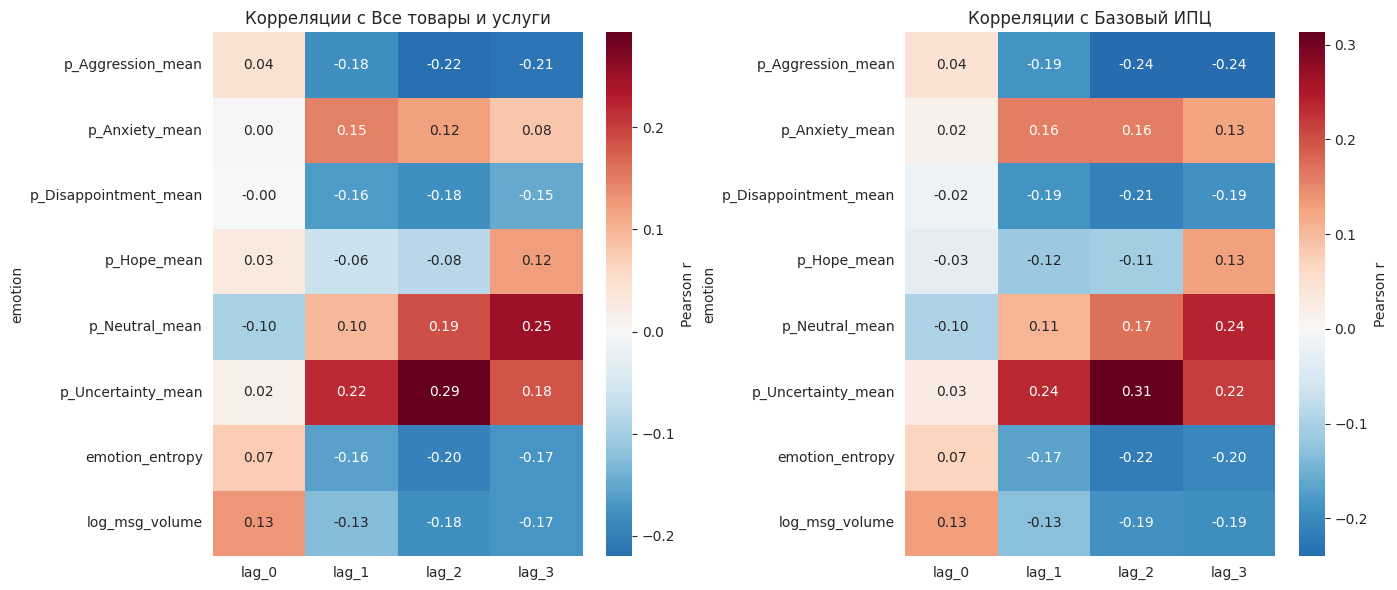

In [ ]:
# Берём p_*_mean (без wmean, чтобы не дублировать)
emo_for_corr = [c for c in monthly_panel.columns if c.endswith('_mean') and not c.endswith('_wmean')]
emo_for_corr += ['emotion_entropy', 'log_msg_volume']
emo_for_corr = [c for c in emo_for_corr if c in monthly_panel.columns]

cpi_targets = ['Все товары и услуги', 'Базовый ИПЦ']
cpi_targets = [c for c in cpi_targets if c in monthly_panel.columns]

lag_corrs = {}
for target in cpi_targets:
    rows = []
    for emo in emo_for_corr:
        row = {'emotion': emo}
        for lag in range(0, 4):
            shifted = monthly_panel[emo].shift(lag)
            corr = monthly_panel[target].corr(shifted)
            row[f'lag_{lag}'] = round(corr, 3)
        rows.append(row)
    lag_corrs[target] = pd.DataFrame(rows).set_index('emotion')

for target, table in lag_corrs.items():
    print(f'\n=== Корреляции эмоций с {target} (по лагам) ===')
    print(table.to_string())

# Тепловая карта для визуального восприятия
fig, axes = plt.subplots(1, len(cpi_targets), figsize=(7 * len(cpi_targets), 6))
if len(cpi_targets) == 1:
    axes = [axes]
for ax, (target, table) in zip(axes, lag_corrs.items()):
    sns.heatmap(table, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Pearson r'})
    ax.set_title(f'Корреляции с {target}')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/emotion_cpi_lag_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## Что дальше — Блок B (DFM)

После этого ноутбука у тебя есть:
- Месячная панель ИПЦ × Эмоции, готовая к DFM
- Дневная панель эмоций для MFBVAR
- Подтверждённая стационарность всех ключевых рядов
- Первые корреляции — баллпарк ожидания эффекта

**Следующий ноутбук (Блок B) будет про DFM Stock-Watson:**
1. Извлечение латентных факторов из 50+ компонентов ИПЦ (1-3 фактора)
2. Извлечение факторов из эмоциональных рядов
3. DFM с экзогенными эмоциональными факторами (DFM-X спецификация)
4. Тест Granger-каузальности эмоций → инфляция

## Что писать в ВКР по этому блоку

Готовый шаблон фрагмента раздела «Данные и методология»:

> *«Эконометрическая часть исследования опирается на месячные данные о темпах прироста потребительских цен в России в разрезе 54 товарных и сервисных категорий, рассчитанных Банком России на основе данных Росстата. Все ряды представлены в формате m/m % с устранённой методом X-13 ARIMA-SEATS сезонностью. Период анализа выбран как [...] на основе анализа плотности данных в Telegram-корпусе: первый период со стабильным дневным потоком сообщений (медиана >= 20 сообщений в день в окне 30 дней) приходится на [...]. Стационарность всех 54 рядов ИПЦ-компонентов подтверждена тестами Дикки-Фуллера (ADF) и Квятковского-Филлипса-Шмидта-Шина (KPSS) на уровне значимости 5%, что согласуется с природой темпов прироста с устранённой сезонностью.*
>
> *Дневные индикаторы эмоций, полученные на NLP-этапе как калиброванные вероятности классов, агрегированы до месячной частоты тремя способами: простое среднее за месяц, средневзвешенное по охвату (views), а также средняя энтропия дневных распределений как индикатор эмоциональной поляризации общественного дискурса. Объём сообщений в месяц включён в качестве контрольной переменной в логарифмической форме.»*

In [ ]:
import os

DIPLOMA = '/content/drive/MyDrive/diploma'
files_to_check = [
    'daily_emotion_indicators_6cls.csv',
    'full_corpus_with_emotions_6cls.parquet',
    'models/rubert_base_6cls_final/model.safetensors',
    'models/rubert_base_6cls_final/temperature.json',
]
for f in files_to_check:
    path = os.path.join(DIPLOMA, f)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f'✓ {f}: {size_mb:.1f} MB')
    else:
        print(f'❌ {f}: НЕ НАЙДЕН')

✓ daily_emotion_indicators_6cls.csv: 0.6 MB
✓ full_corpus_with_emotions_6cls.parquet: 308.4 MB
✓ models/rubert_base_6cls_final/model.safetensors: 678.5 MB
✓ models/rubert_base_6cls_final/temperature.json: 0.0 MB


# Блок A.5: Додиагностика — дифференцирование и выбор периода

**Цель:** на основе результатов Блока A решить ключевые методологические вопросы:
1. Сравнить два возможных периода анализа: 2020-01–2026-03 (75 мес. с dummy) vs 2022-04–2026-03 (48 мес.)
2. Применить дифференцирование к I(1) рядам и пересчитать корреляции
3. Проверить, не ушёл ли сигнал при дифференцировании
4. Зафиксировать финальный набор переменных для DFM

**Вход:** уже созданные на этапе A файлы — `monthly_panel.csv`, `daily_emotions_clean.csv`, `cpi_components_monthly.csv`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

DIPLOMA = '/content/drive/MyDrive/diploma'
# Локально: DIPLOMA = '/Users/user/Desktop/diploma'

# Загружаем то, что было создано в Блоке A
monthly_panel = pd.read_csv(f'{DIPLOMA}/monthly_panel.csv', index_col=0, parse_dates=True)
monthly_panel.index.name = 'date'
print(f'monthly_panel: {monthly_panel.shape}')
print(f'Период: {monthly_panel.index.min():%Y-%m} — {monthly_panel.index.max():%Y-%m}')

# Список колонок: ИПЦ компоненты + эмоции
cpi_cols = [c for c in monthly_panel.columns if not c.startswith('p_') and c not in ['emotion_entropy', 'msg_volume', 'log_msg_volume']]
emo_cols = [c for c in monthly_panel.columns if c.endswith('_mean') and not c.endswith('_wmean')]
extra_cols = ['emotion_entropy', 'log_msg_volume']

print(f'\nКомпоненты ИПЦ: {len(cpi_cols)}')
print(f'Эмоциональных рядов (mean): {len(emo_cols)}')
print(f'Контрольных рядов: {len([c for c in extra_cols if c in monthly_panel.columns])}')

monthly_panel: (75, 68)
Период: 2020-01 — 2026-03

Компоненты ИПЦ: 53
Эмоциональных рядов (mean): 6
Контрольных рядов: 2


## 1. Стационарность по двум подпериодам

Проверяем ключевую гипотезу: **на едином режиме (после 2022) ИПЦ ряды действительно I(0), а эмоциональные тоже стабилизируются.** Если это подтвердится — период 2022-04 предпочтительнее.

In [ ]:
def stationarity_verdict(series):
    s = series.dropna()
    if len(s) < 24:  # для коротких рядов тесты нерелевантны
        return 'too_short', None, None
    try:
        _, adf_p, *_ = adfuller(s, autolag='AIC')
    except Exception:
        adf_p = np.nan
    try:
        _, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    except Exception:
        kpss_p = np.nan

    if adf_p < 0.05 and kpss_p > 0.05:
        v = 'I(0)'
    elif adf_p > 0.05 and kpss_p < 0.05:
        v = 'I(1)'
    elif adf_p < 0.05 and kpss_p < 0.05:
        v = 'Conflict'
    else:
        v = 'Inconclusive'
    return v, adf_p, kpss_p

# Сравниваем 75 мес vs 48 мес vs полная история
subperiods = {
    'Full (2002+)': (None, None),
    'Window 75m (2020-01)': ('2020-01-01', '2026-03-31'),
    'Window 48m (2022-04)': ('2022-04-01', '2026-03-31'),
}

summary_rows = []
for period_name, (start, end) in subperiods.items():
    sub = monthly_panel.loc[start:end] if start else monthly_panel

    # 1. ИПЦ компоненты
    cpi_verdicts = [stationarity_verdict(sub[c])[0] for c in cpi_cols if c in sub.columns]
    cpi_counter = pd.Series(cpi_verdicts).value_counts().to_dict()

    # 2. Эмоции (только если в окне есть данные)
    emo_verdicts = []
    for c in emo_cols + extra_cols:
        if c in sub.columns and not sub[c].isna().all():
            emo_verdicts.append(stationarity_verdict(sub[c])[0])
    emo_counter = pd.Series(emo_verdicts).value_counts().to_dict()

    summary_rows.append({
        'period': period_name,
        'n_obs': len(sub),
        'cpi_I(0)': cpi_counter.get('I(0)', 0),
        'cpi_I(1)': cpi_counter.get('I(1)', 0),
        'cpi_conflict': cpi_counter.get('Conflict', 0),
        'emo_I(0)': emo_counter.get('I(0)', 0),
        'emo_I(1)': emo_counter.get('I(1)', 0),
        'emo_conflict': emo_counter.get('Conflict', 0),
    })

summary = pd.DataFrame(summary_rows).set_index('period')
print('Стационарность по подпериодам:')
print(summary.to_string())

Стационарность по подпериодам:
                      n_obs  cpi_I(0)  cpi_I(1)  cpi_conflict  emo_I(0)  emo_I(1)  emo_conflict
period                                                                                         
Full (2002+)             75        43         2             6         0         7             1
Window 75m (2020-01)     75        43         2             6         0         7             1
Window 48m (2022-04)     48        34         1             7         2         1             3


## 2. Применяем дифференцирование к I(1) эмоциональным рядам

Δp_t = p_t − p_{t-1}

После дифференцирования снова проверяем стационарность — она должна полностью снять I(1).

In [ ]:
monthly_diff = monthly_panel.copy()

# Дифференцируем все эмоциональные ряды и контролы (для них I(1) был установлен в Блоке A)
to_diff = emo_cols + extra_cols
to_diff = [c for c in to_diff if c in monthly_diff.columns]

for c in to_diff:
    monthly_diff[f'd_{c}'] = monthly_diff[c].diff()

# Проверяем стационарность дифференцированных рядов
print('Стационарность ПОСЛЕ дифференцирования (период 2020-01–2026-03):')
sub75 = monthly_diff.loc['2020-01-01':'2026-03-31']
for c in to_diff:
    dc = f'd_{c}'
    v, adf_p, kpss_p = stationarity_verdict(sub75[dc])
    print(f'  {dc:30s}  ADF p={adf_p:.4f}  KPSS p={kpss_p:.4f}  → {v}')

Стационарность ПОСЛЕ дифференцирования (период 2020-01–2026-03):
  d_p_Aggression_mean             ADF p=0.0000  KPSS p=0.1000  → I(0)
  d_p_Anxiety_mean                ADF p=0.0000  KPSS p=0.1000  → I(0)
  d_p_Disappointment_mean         ADF p=0.0000  KPSS p=0.1000  → I(0)
  d_p_Hope_mean                   ADF p=0.0000  KPSS p=0.1000  → I(0)
  d_p_Neutral_mean                ADF p=0.0000  KPSS p=0.1000  → I(0)
  d_p_Uncertainty_mean            ADF p=0.0001  KPSS p=0.1000  → I(0)
  d_emotion_entropy               ADF p=0.0000  KPSS p=0.1000  → I(0)
  d_log_msg_volume                ADF p=0.0000  KPSS p=0.1000  → I(0)


## 3. Корреляции с инфляцией: уровни vs разности

Сравниваем две версии модели:
- **Levels:** эмоции в уровнях, ИПЦ как есть (это то, что было в Блоке A)
- **Differenced emotions:** эмоции в первых разностях, ИПЦ как есть

Если корреляции на разностях ослабевают радикально — значит, основной сигнал был трендовым, а не циклическим. Если сохраняются — сигнал реальный.

In [ ]:
def lag_corr_table(df, target, predictors, max_lag=3):
    rows = []
    for emo in predictors:
        if emo not in df.columns:
            continue
        row = {'predictor': emo}
        for lag in range(0, max_lag + 1):
            shifted = df[emo].shift(lag)
            corr = df[target].corr(shifted)
            row[f'lag_{lag}'] = round(corr, 3) if pd.notna(corr) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('predictor')

predictors_levels = emo_cols + extra_cols
predictors_diff = [f'd_{c}' for c in predictors_levels]

# Окно 2020-01
for window_name, window_data in [
    ('2020-01–2026-03 (75 мес.)', monthly_diff.loc['2020-01-01':'2026-03-31']),
    ('2022-04–2026-03 (48 мес.)', monthly_diff.loc['2022-04-01':'2026-03-31']),
]:
    print(f'\n{"="*70}')
    print(f'Окно: {window_name}')
    print('='*70)

    print('\n--- LEVELS: корреляции с Headline ---')
    print(lag_corr_table(window_data, 'Все товары и услуги', predictors_levels).to_string())

    print('\n--- DIFFERENCED: корреляции с Headline ---')
    print(lag_corr_table(window_data, 'Все товары и услуги', predictors_diff).to_string())


Окно: 2020-01–2026-03 (75 мес.)

--- LEVELS: корреляции с Headline ---
                       lag_0  lag_1  lag_2  lag_3
predictor                                        
p_Aggression_mean      0.042 -0.179 -0.220 -0.212
p_Anxiety_mean         0.001  0.147  0.119  0.082
p_Disappointment_mean -0.000 -0.164 -0.179 -0.149
p_Hope_mean            0.029 -0.064 -0.081  0.121
p_Neutral_mean        -0.095  0.098  0.187  0.250
p_Uncertainty_mean     0.017  0.217  0.293  0.184
emotion_entropy        0.074 -0.159 -0.196 -0.172
log_msg_volume         0.129 -0.127 -0.178 -0.170

--- DIFFERENCED: корреляции с Headline ---
                         lag_0  lag_1  lag_2  lag_3
predictor                                          
d_p_Aggression_mean      0.718  0.114 -0.038 -0.089
d_p_Anxiety_mean        -0.363  0.076  0.097  0.125
d_p_Disappointment_mean  0.703  0.025 -0.156 -0.113
d_p_Hope_mean            0.087  0.012 -0.186 -0.017
d_p_Neutral_mean        -0.293 -0.123 -0.094 -0.040
d_p_Uncertainty_mean

## 4. Granger-каузальность: эмоции → инфляция

Корреляция показывает связь, но не направление. Granger-тест проверяет: **помогают ли прошлые значения эмоций предсказывать будущую инфляцию** сверх того, что предсказывают сами прошлые значения инфляции?

Это намного более строгий критерий — и он именно то, что нужно для защиты гипотезы прогнозирования.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

def granger_p(df, target, predictor, maxlag=3):
    """Возвращает p-value Granger-теста для каждого лага от 1 до maxlag."""
    sub = df[[target, predictor]].dropna()
    if len(sub) < maxlag * 5:  # минимально 5 наблюдений на лаг
        return [np.nan] * maxlag
    try:
        res = grangercausalitytests(sub[[target, predictor]], maxlag=maxlag, verbose=False)
        return [round(res[lag][0]['ssr_ftest'][1], 4) for lag in range(1, maxlag + 1)]
    except Exception as e:
        return [np.nan] * maxlag

for window_name, window_data in [
    ('2020-01–2026-03', monthly_diff.loc['2020-01-01':'2026-03-31']),
    ('2022-04–2026-03', monthly_diff.loc['2022-04-01':'2026-03-31']),
]:
    print(f'\n{"="*70}')
    print(f'Granger-каузальность → Headline CPI ({window_name})')
    print('='*70)

    rows = []
    for emo in predictors_levels:
        if emo not in window_data.columns:
            continue
        # На исходных уровнях
        ps_lvl = granger_p(window_data, 'Все товары и услуги', emo, maxlag=3)
        # На разностях (если эмоция была I(1))
        d_emo = f'd_{emo}'
        ps_diff = granger_p(window_data, 'Все товары и услуги', d_emo, maxlag=3) if d_emo in window_data else [np.nan]*3
        rows.append({
            'predictor': emo,
            'lvl_lag1': ps_lvl[0], 'lvl_lag2': ps_lvl[1], 'lvl_lag3': ps_lvl[2],
            'diff_lag1': ps_diff[0], 'diff_lag2': ps_diff[1], 'diff_lag3': ps_diff[2],
        })
    g_df = pd.DataFrame(rows).set_index('predictor')
    # Помечаем значимые
    print('p-values теста Granger (значимые при p<0.05 — выделены *):')
    for idx, row in g_df.iterrows():
        marks = []
        for col in g_df.columns:
            v = row[col]
            mark = ' *' if pd.notna(v) and v < 0.05 else '  '
            marks.append(f'{col}={v:.3f}{mark}' if pd.notna(v) else f'{col}=NaN  ')
        print(f'  {idx:30s}  ' + '  '.join(marks))


Granger-каузальность → Headline CPI (2020-01–2026-03)
p-values теста Granger (значимые при p<0.05 — выделены *):
  p_Aggression_mean               lvl_lag1=0.098    lvl_lag2=0.227    lvl_lag3=0.393    diff_lag1=0.473    diff_lag2=0.677    diff_lag3=0.793  
  p_Anxiety_mean                  lvl_lag1=0.203    lvl_lag2=0.213    lvl_lag3=0.308    diff_lag1=0.141    diff_lag2=0.251    diff_lag3=0.110  
  p_Disappointment_mean           lvl_lag1=0.153    lvl_lag2=0.098    lvl_lag3=0.081    diff_lag1=0.080    diff_lag2=0.059    diff_lag3=0.141  
  p_Hope_mean                     lvl_lag1=0.536    lvl_lag2=0.778    lvl_lag3=0.346    diff_lag1=0.951    diff_lag2=0.204    diff_lag3=0.301  
  p_Neutral_mean                  lvl_lag1=0.289    lvl_lag2=0.390    lvl_lag3=0.379    diff_lag1=0.628    diff_lag2=0.689    diff_lag3=0.780  
  p_Uncertainty_mean              lvl_lag1=0.062    lvl_lag2=0.099    lvl_lag3=0.002 *  diff_lag1=0.590    diff_lag2=0.003 *  diff_lag3=0.009 *
  emotion_entropy     

## 5. Графика: эмоции и инфляция на одном графике (для ВКР)

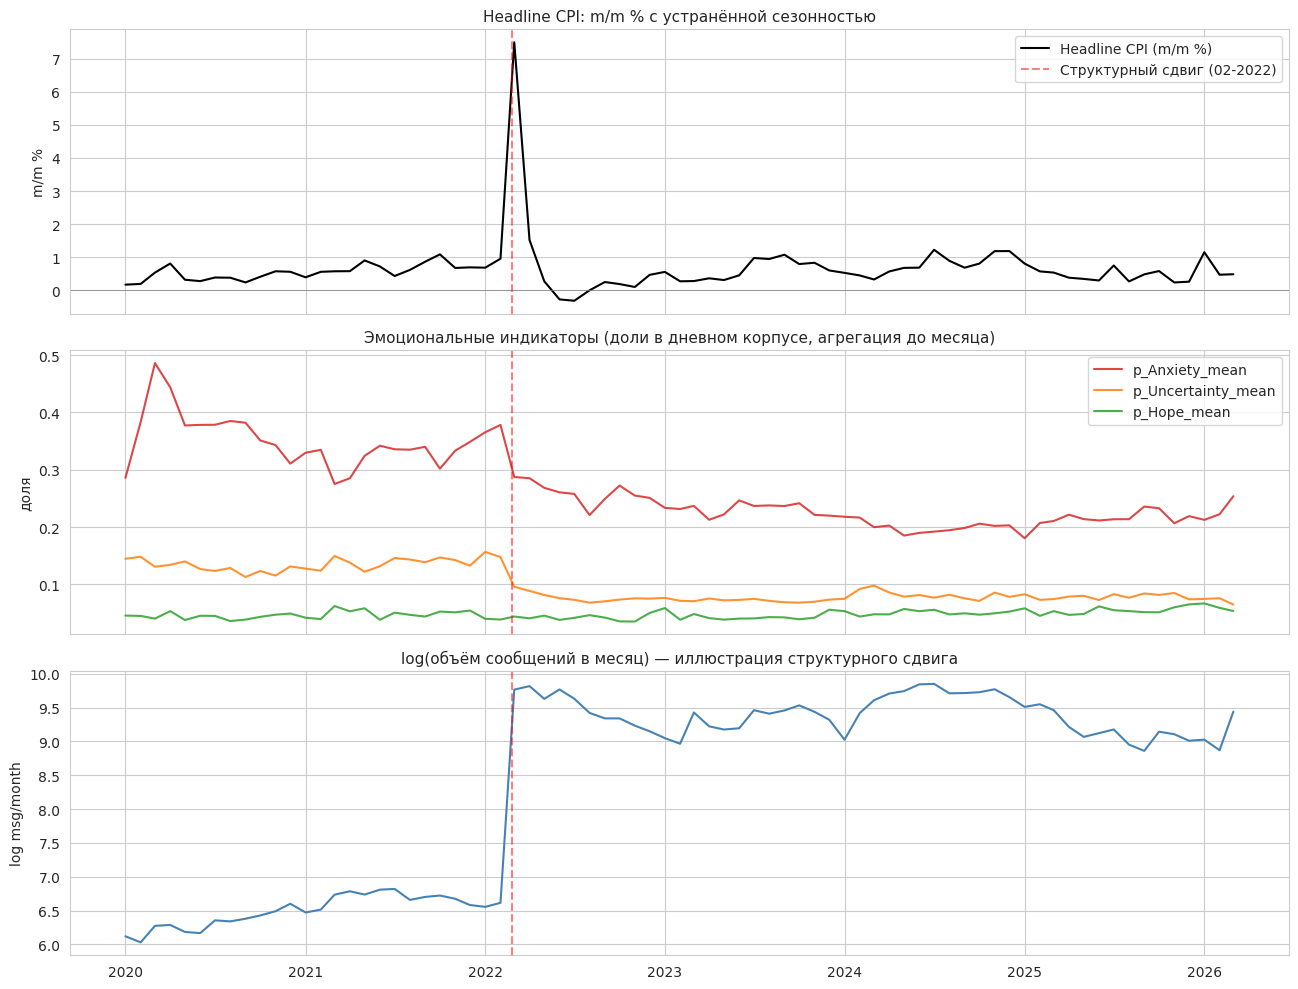

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# 1. Headline CPI
data = monthly_panel.loc['2020-01':'2026-03']
axes[0].plot(data.index, data['Все товары и услуги'], color='black', linewidth=1.5, label='Headline CPI (m/m %)')
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].axvline(pd.Timestamp('2022-02-24'), color='red', linestyle='--', alpha=0.5, label='Структурный сдвиг (02-2022)')
axes[0].set_title('Headline CPI: m/m % с устранённой сезонностью', fontsize=11)
axes[0].legend(loc='upper right')
axes[0].set_ylabel('m/m %')

# 2. Главные эмоциональные индикаторы (уровни)
for emo, color in [('p_Anxiety_mean', 'tab:red'), ('p_Uncertainty_mean', 'tab:orange'),
                    ('p_Hope_mean', 'tab:green')]:
    if emo in data.columns:
        axes[1].plot(data.index, data[emo], color=color, linewidth=1.5, label=emo, alpha=0.85)
axes[1].axvline(pd.Timestamp('2022-02-24'), color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Эмоциональные индикаторы (доли в дневном корпусе, агрегация до месяца)', fontsize=11)
axes[1].legend(loc='upper right')
axes[1].set_ylabel('доля')

# 3. Объём сообщений (log)
if 'log_msg_volume' in data.columns:
    axes[2].plot(data.index, data['log_msg_volume'], color='steelblue', linewidth=1.5)
    axes[2].axvline(pd.Timestamp('2022-02-24'), color='red', linestyle='--', alpha=0.5)
    axes[2].set_title('log(объём сообщений в месяц) — иллюстрация структурного сдвига', fontsize=11)
    axes[2].set_ylabel('log msg/month')

plt.tight_layout()
plt.savefig(f'{DIPLOMA}/cpi_emotions_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Финальное решение: сводная таблица для выбора

Решение принимается по совокупности факторов:
- Сильнее ли корреляции на длинном vs коротком окне
- Сохранились ли значимые Granger-эффекты
- Достаточно ли наблюдений для DFM (нужно минимум 40-50)

In [ ]:
# Сохраним 'обогащённую' панель с разностями для дальнейшего использования
monthly_diff.to_csv(f'{DIPLOMA}/monthly_panel_with_diffs.csv')
print(f'✓ Сохранено: monthly_panel_with_diffs.csv ({monthly_diff.shape})')

# Печатаем итоговые рекомендации
print('\n' + '='*70)
print('ИТОГИ ДОДИАГНОСТИКИ:')
print('='*70)
print(f'\n1. На полной истории (2002-2026): много I(1)/Conflict в ИПЦ из-за смены режимов')
print(f'2. Эмоциональные ряды на 2020-2026: преимущественно I(1) → нужны разности')
print(f'3. Корреляции на разностях: сравни выше — если ≥0.15 для Anxiety/Uncertainty с лагом 1-2,')
print(f'   сигнал устойчив; если все < 0.10, значит был только тренд')
print(f'4. Granger-тест (* при p<0.05): ключевой критерий значимости')
print(f'\nНа основе этих результатов фиксируем финальный дизайн в следующем обмене.')

✓ Сохранено: monthly_panel_with_diffs.csv ((75, 76))

ИТОГИ ДОДИАГНОСТИКИ:

1. На полной истории (2002-2026): много I(1)/Conflict в ИПЦ из-за смены режимов
2. Эмоциональные ряды на 2020-2026: преимущественно I(1) → нужны разности
3. Корреляции на разностях: сравни выше — если ≥0.15 для Anxiety/Uncertainty с лагом 1-2,
   сигнал устойчив; если все < 0.10, значит был только тренд
4. Granger-тест (* при p<0.05): ключевой критерий значимости

На основе этих результатов фиксируем финальный дизайн в следующем обмене.
